# PASO 8 – INTERPRETABILIDAD CON SHAP

### Configuración del entorno (ejecutar UNA sola vez en terminal):
```bash
conda create -n tfm_shap python=3.10 -y
conda activate tfm_shap
pip install shap scikit-learn pandas numpy matplotlib seaborn xgboost lightgbm
```

### Por qué dos entornos:
- **`tfm`** → numpy antiguo + mordred + rdkit (pasos 3-7, ya ejecutados)
- **`tfm_shap`** → numpy moderno + shap (paso 8)

### Input requerido:
- `paso4_descriptores_mordred.csv` → descriptores ya calculados con mordred
- `paso5_feature_sets.csv` → resumen de feature sets (generado en paso 5)

Este notebook reconstruye los mejores modelos (ya sabes cuáles son del paso 7)
y aplica SHAP + permutation importance sobre ellos.

## 0. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

import shap
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, classification_report, matthews_corrcoef

# Modelos (mismos que en el entorno tfm)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, AdaBoostClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import SGDClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

print(f"shap version: {shap.__version__}")
print(f"numpy version: {np.__version__}")

RANDOM_STATE = 42
OUTPUT_DIR   = "resultados_shap"
os.makedirs(OUTPUT_DIR, exist_ok=True)

shap version: 0.51.0
numpy version: 2.4.4


## 1. Cargar descriptores ya calculados con Mordred

No hace falta recalcular nada. Leemos directamente el CSV del paso 4.

In [2]:
# Carga del CSV de descriptores generado en el entorno tfm (paso 4)
df_desc_full = pd.read_csv('paso4_descriptores_mordred.csv')

# Separar IDs, etiquetas y descriptores
chembl_ids = df_desc_full['ChEMBL_ID'].values
y          = df_desc_full['Label'].values
X_full     = df_desc_full.drop(columns=['ChEMBL_ID', 'Label'])

print(f"Compuestos: {len(y)}")
print(f"Descriptores: {X_full.shape[1]}")
print(f"Activos: {y.sum()} ({y.mean():.1%}) | Inactivos: {(y==0).sum()}")

Compuestos: 537
Descriptores: 944
Activos: 250 (46.6%) | Inactivos: 287


## 2. Reproducir los feature sets del paso 5

Reconstruimos los mismos feature sets usando los mismos umbrales de correlación.

In [3]:
def correlation_filter(X: pd.DataFrame, threshold: float, method: str = 'pearson') -> list:
    """Misma función que en el entorno tfm (paso 5)."""
    corr_matrix = X.corr(method=method).abs()
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    to_drop  = {col for col in upper.columns if any(upper[col] >= threshold)}
    retained = [col for col in X.columns if col not in to_drop]
    return retained

CORR_THRESHOLDS = [0.7, 0.8, 0.9]
feature_sets = {}

for thr in CORR_THRESHOLDS:
    for method in ['pearson', 'spearman']:
        key      = f'{method}_thr{thr}'
        retained = correlation_filter(X_full, thr, method)
        feature_sets[key] = retained
        print(f'  {key:30s} → {len(retained):4d} descriptores')

feature_sets['no_filter'] = list(X_full.columns)
print(f"  {'no_filter':30s} → {len(X_full.columns):4d} descriptores")

  pearson_thr0.7                 →  111 descriptores
  spearman_thr0.7                →  117 descriptores
  pearson_thr0.8                 →  192 descriptores
  spearman_thr0.8                →  184 descriptores
  pearson_thr0.9                 →  338 descriptores
  spearman_thr0.9                →  318 descriptores
  no_filter                      →  944 descriptores


## 3. Reproducir el train/test split (mismos parámetros que paso 6)

In [4]:
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE   # ← mismo random_state que en paso 6
)
print(f"Train: {len(y_train)} | Test: {len(y_test)}")

Train: 429 | Test: 108


## 4. Reentrenar el TOP 3 de modelos

Cambia `TOP3_MODELS` con los 3 mejores modelos que obtuviste en el paso 7.

Formato: `(nombre_modelo, feature_set, estimador, param_grid)`

In [6]:
# ── ✏️ EDITA AQUÍ con tus top 3 modelos del paso 7 ──────────────────────────
# Según los resultados de tu notebook: el mejor fue LogisticRegression / spearman_thr0.7
# Pon los 3 mejores que viste en df_results del paso 7

TOP6_MODELS = [
    (
        'LogisticRegression', 'spearman_thr0.7',
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        {'clf__C': [ 0.1],
         'clf__solver': ['lbfgs'],
         'clf__penalty': ['l2']}
    ),
    (
        "AdaBoost", 'spearman_thr0.7',
        AdaBoostClassifier(random_state=42),
        {
            "clf__n_estimators" : [100],
            "clf__learning_rate": [0.5],
        }
    ),
    (
        'SVM_RBF', 'spearman_thr0.7',          
        SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
        {'clf__C': [1],
         'clf__gamma': ['scale', 'auto', 0.01]}
    ),
    (
        'LogisticRegression', 'pearson_thr0.7',
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        {'clf__C': [ 0.1],
         'clf__solver': ['lbfgs'],
         'clf__penalty': ['l2']}
    ),
    (
        "AdaBoost", 'pearson_thr0.7',
        AdaBoostClassifier(random_state=42),
        {
            "clf__n_estimators" : [50],
            "clf__learning_rate": [ 1.0],
        }
    ),
    (
        'SVM_RBF', 'pearson_thr0.7',          # ← cambia según tus resultados
        SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
        {'clf__C': [1],
         'clf__gamma': ['scale', 'auto', 0.01]}
    ),
]
# ─────────────────────────────────────────────────────────────────────────────

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
best_estimators = {}

for model_name, fs_name, estimator, param_grid in TOP6_MODELS:
    key    = f'{model_name}__{fs_name}'
    fs_cols = feature_sets[fs_name]
    X_tr   = X_train_full[fs_cols]

    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('clf',     estimator),
    ])

    gs = GridSearchCV(pipe, param_grid, cv=cv,
                      scoring='roc_auc', n_jobs=-1, refit=True)
    gs.fit(X_tr, y_train)
    best_estimators[key] = gs.best_estimator_

    y_prob = gs.best_estimator_.predict_proba(X_test_full[fs_cols])[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    print(f'  {key}: CV AUC={gs.best_score_:.3f} | Test AUC={auc:.3f}')
    print(f'  Mejores parámetros: {gs.best_params_}')

  LogisticRegression__spearman_thr0.7: CV AUC=0.901 | Test AUC=0.959
  Mejores parámetros: {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
  AdaBoost__spearman_thr0.7: CV AUC=0.917 | Test AUC=0.950
  Mejores parámetros: {'clf__learning_rate': 0.5, 'clf__n_estimators': 100}
  SVM_RBF__spearman_thr0.7: CV AUC=0.922 | Test AUC=0.968
  Mejores parámetros: {'clf__C': 1, 'clf__gamma': 0.01}
  LogisticRegression__pearson_thr0.7: CV AUC=0.902 | Test AUC=0.950
  Mejores parámetros: {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
  AdaBoost__pearson_thr0.7: CV AUC=0.922 | Test AUC=0.950
  Mejores parámetros: {'clf__learning_rate': 1.0, 'clf__n_estimators': 50}
  SVM_RBF__pearson_thr0.7: CV AUC=0.917 | Test AUC=0.961
  Mejores parámetros: {'clf__C': 1, 'clf__gamma': 0.01}


## 5. Permutation Importance (model-agnostic, funciona con cualquier modelo)


── #1: LogisticRegression (spearman_thr0.7) ──
Calculando permutation importance...


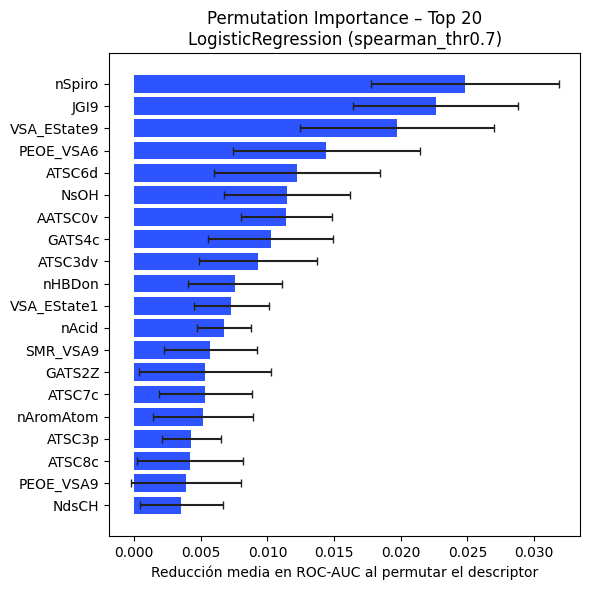

Top 5 descriptores:
         feature  importance_mean  importance_std
4         nSpiro         0.024816        0.007019
114         JGI9         0.022621        0.006186
97   VSA_EState9         0.019736        0.007266
80     PEOE_VSA6         0.014414        0.007009
30        ATSC6d         0.012230        0.006242

── #2: AdaBoost (spearman_thr0.7) ──
Calculando permutation importance...


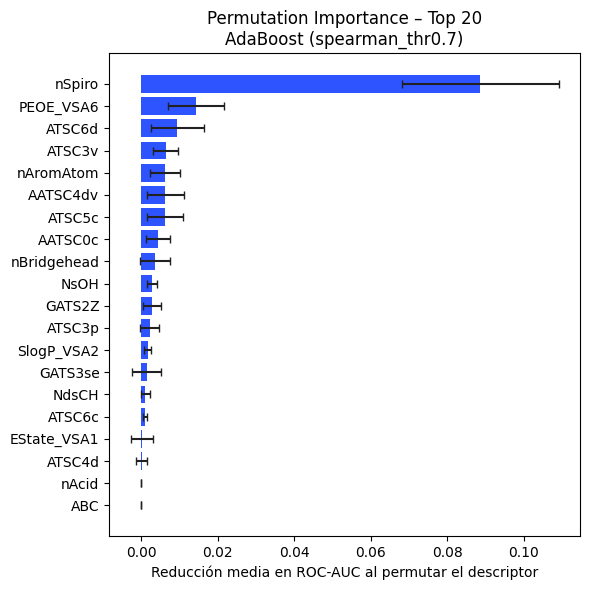

Top 5 descriptores:
      feature  importance_mean  importance_std
4      nSpiro         0.088621        0.020497
80  PEOE_VSA6         0.014253        0.007327
30     ATSC6d         0.009448        0.007005
33     ATSC3v         0.006460        0.003280
3   nAromAtom         0.006345        0.003929

── #3: SVM_RBF (spearman_thr0.7) ──
Calculando permutation importance...


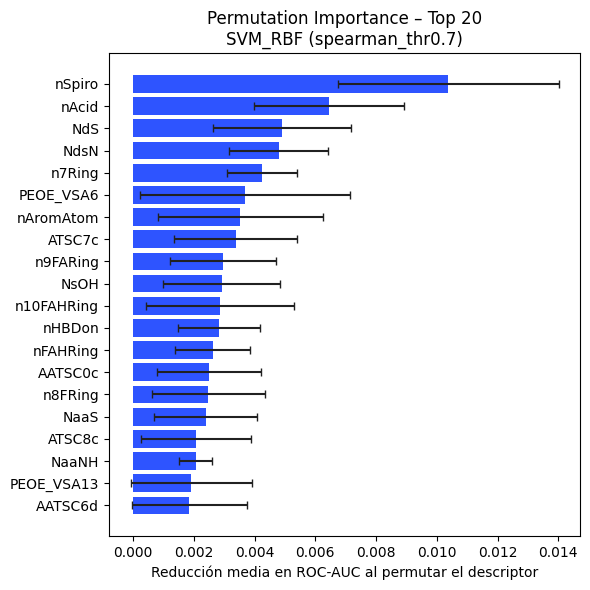

Top 5 descriptores:
   feature  importance_mean  importance_std
4   nSpiro         0.010379        0.003629
1    nAcid         0.006448        0.002455
74     NdS         0.004908        0.002275
65    NdsN         0.004793        0.001621
99  n7Ring         0.004230        0.001154

── #4: LogisticRegression (pearson_thr0.7) ──
Calculando permutation importance...


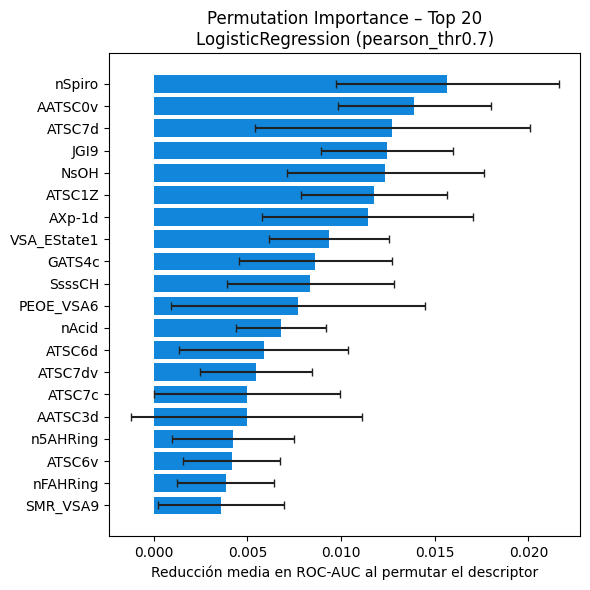

Top 5 descriptores:
     feature  importance_mean  importance_std
4     nSpiro         0.015655        0.005952
41   AATSC0v         0.013908        0.004093
27    ATSC7d         0.012736        0.007325
107     JGI9         0.012448        0.003537
64      NsOH         0.012368        0.005268

── #5: AdaBoost (pearson_thr0.7) ──
Calculando permutation importance...


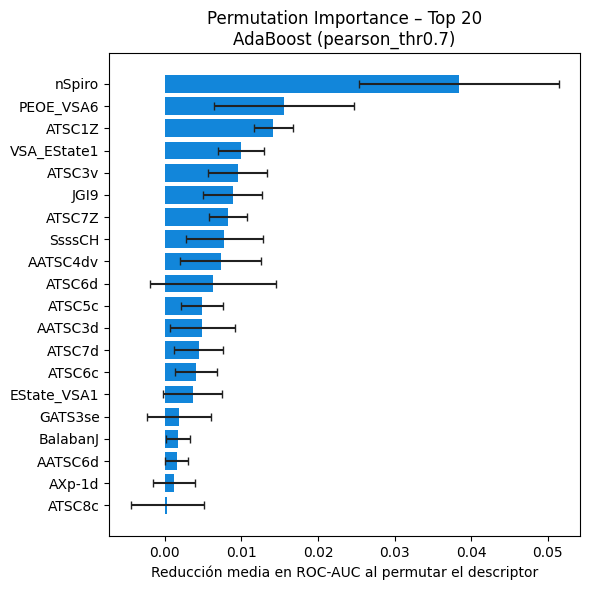

Top 5 descriptores:
        feature  importance_mean  importance_std
4        nSpiro         0.038368        0.013062
74    PEOE_VSA6         0.015540        0.009117
29       ATSC1Z         0.014184        0.002521
87  VSA_EState1         0.009931        0.003046
33       ATSC3v         0.009540        0.003837

── #6: SVM_RBF (pearson_thr0.7) ──
Calculando permutation importance...


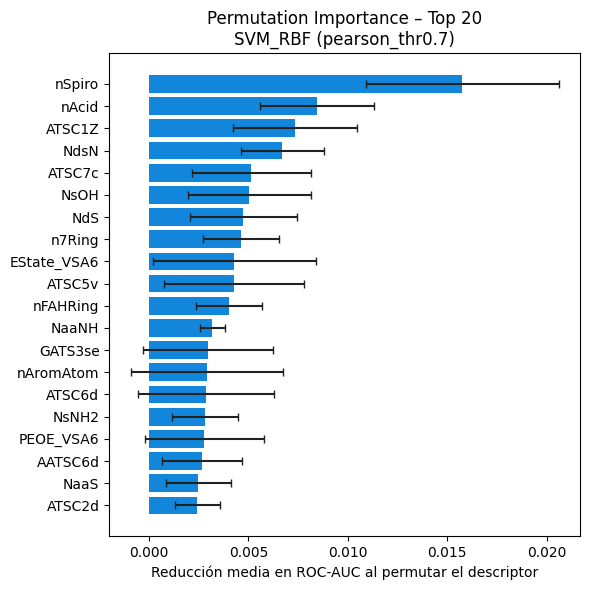

Top 5 descriptores:
   feature  importance_mean  importance_std
4   nSpiro         0.015759        0.004848
1    nAcid         0.008448        0.002879
29  ATSC1Z         0.007356        0.003124
60    NdsN         0.006701        0.002078
18  ATSC7c         0.005149        0.002995


In [8]:
for rank, (model_name, fs_name, _, _) in enumerate(TOP6_MODELS, start=1):
    key     = f'{model_name}__{fs_name}'
    est     = best_estimators[key]
    fs_cols = feature_sets[fs_name]
    X_te_fs = X_test_full[fs_cols]

    print(f'\n── #{rank}: {model_name} ({fs_name}) ──')
    print('Calculando permutation importance...')

    perm = permutation_importance(
        est, X_te_fs, y_test,
        n_repeats=30,
        random_state=RANDOM_STATE,
        scoring='roc_auc',
        n_jobs=-1,
    )

    perm_df = pd.DataFrame({
        'feature'         : fs_cols,
        'importance_mean' : perm.importances_mean,
        'importance_std'  : perm.importances_std,
    }).sort_values('importance_mean', ascending=False)

    perm_df.to_csv(f'{OUTPUT_DIR}/permutation_importance_{rank}_{model_name}.csv',
                  index=False)
    
    if 'pearson' in fs_name.lower():
        color_grafico = "#1286DA"       # Azul Marino
    elif 'spearman' in fs_name.lower():
        color_grafico = '#2E54FF'    # Celeste
    else:
        color_grafico = '#4C72B0'

    # Gráfico top 20
    top20 = perm_df.head(20)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.barh(top20['feature'][::-1], top20['importance_mean'][::-1],
            xerr=top20['importance_std'][::-1],
            color=color_grafico, ecolor='#212121', capsize=3)
    ax.set_title(f'Permutation Importance – Top 20\n{model_name} ({fs_name})')
    ax.set_xlabel('Reducción media en ROC-AUC al permutar el descriptor')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/permutation_{rank}_{model_name}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Top 5 descriptores:')
    print(perm_df.head())

In [26]:
print(f"Total de muestras en el set de test: {len(X_test_full)}")

Total de muestras en el set de test: 108


## 6. SHAP – Análisis de interpretabilidad

- **TreeExplainer**: exacto y rápido para modelos basados en árboles (RF, GBM, XGB, ET)
- **LinearExplainer**: exacto para modelos lineales (LogisticRegression, SVM lineal)
- **KernelExplainer**: model-agnostic, funciona para cualquier modelo (más lento)


══ SHAP #1: LogisticRegression (spearman_thr0.7) ══
  Usando LinearExplainer...


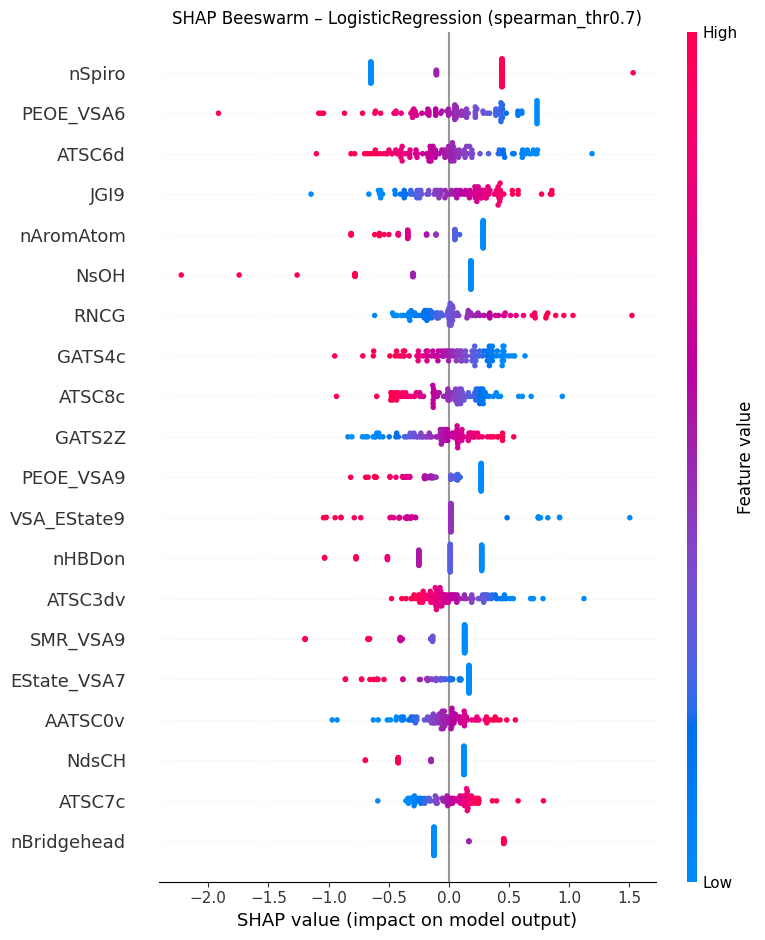

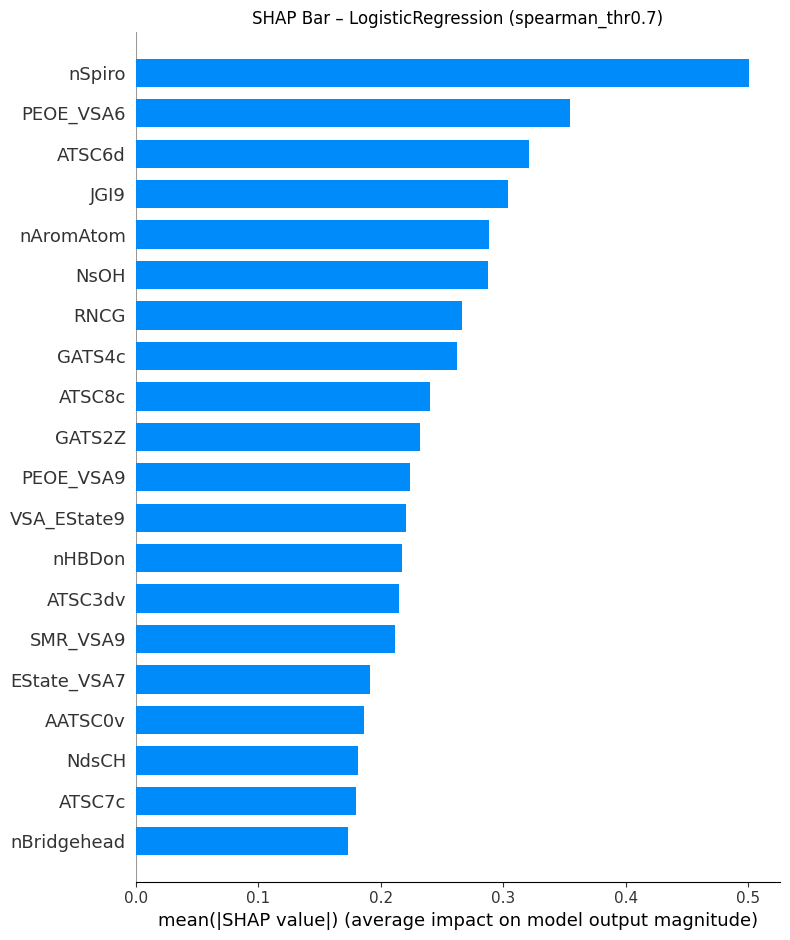

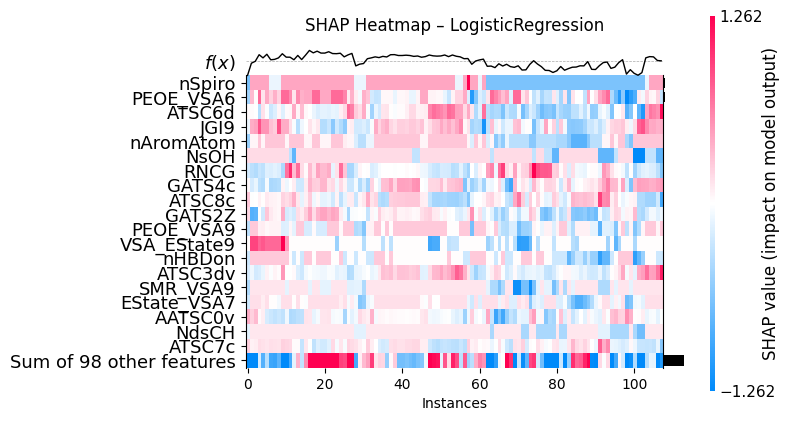


  Top 10 descriptores más influyentes (LogisticRegression):
descriptor  mean_abs_shap
    nSpiro       0.500693
 PEOE_VSA6       0.354047
    ATSC6d       0.321116
      JGI9       0.303378
 nAromAtom       0.288030
      NsOH       0.287737
      RNCG       0.266363
    GATS4c       0.262157
    ATSC8c       0.240228
    GATS2Z       0.231642

══ SHAP #2: AdaBoost (spearman_thr0.7) ══
  Usando KernelExplainer (puede tardar varios minutos)...


100%|██████████| 108/108 [03:47<00:00,  2.11s/it]


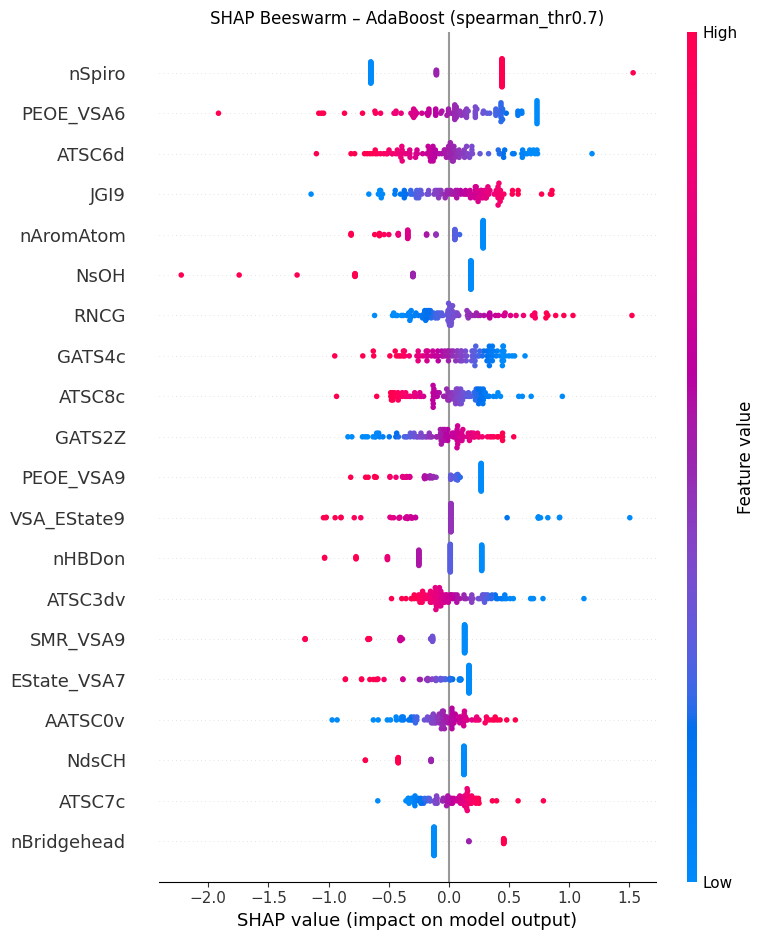

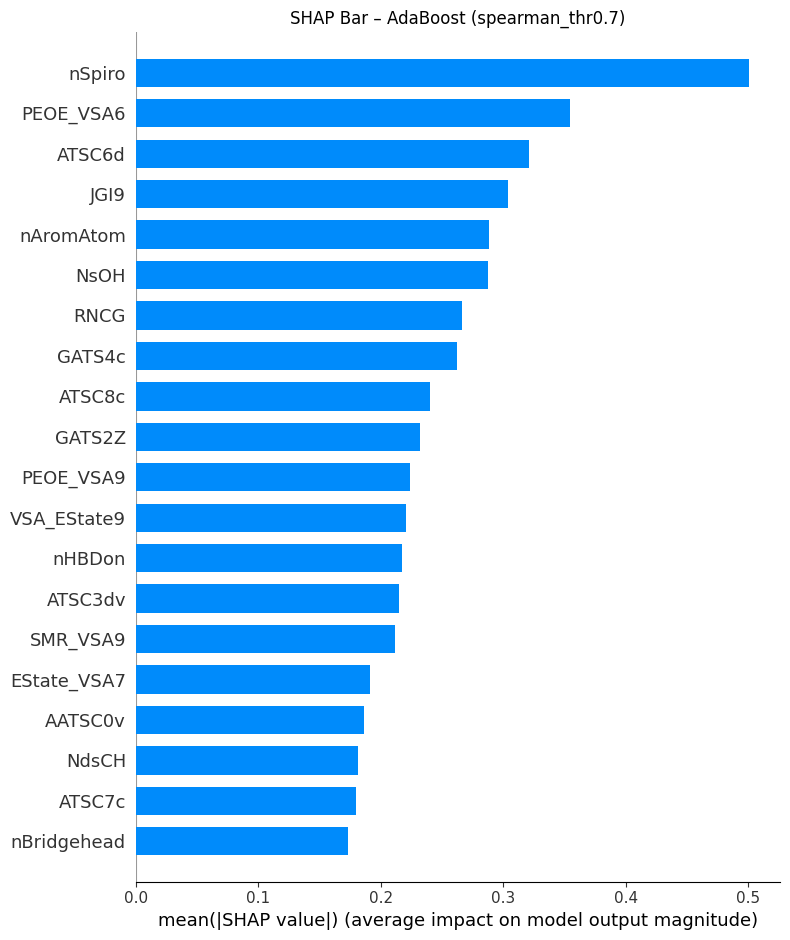

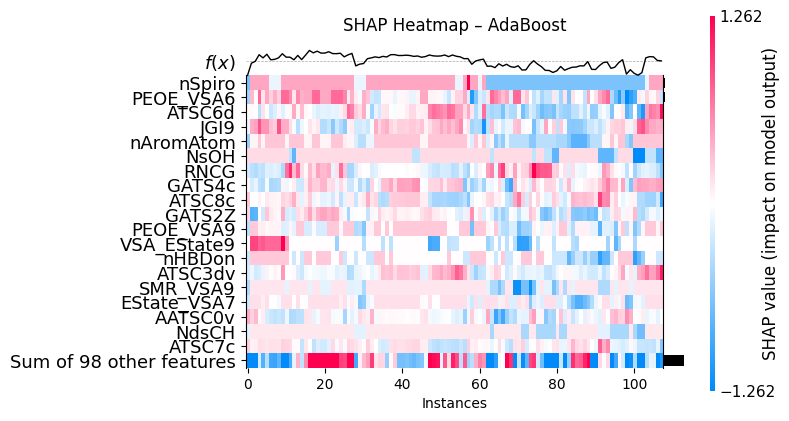


  Top 10 descriptores más influyentes (AdaBoost):
descriptor  mean_abs_shap
    nSpiro       0.500693
 PEOE_VSA6       0.354047
    ATSC6d       0.321116
      JGI9       0.303378
 nAromAtom       0.288030
      NsOH       0.287737
      RNCG       0.266363
    GATS4c       0.262157
    ATSC8c       0.240228
    GATS2Z       0.231642

══ SHAP #3: SVM_RBF (spearman_thr0.7) ══
  Usando KernelExplainer (puede tardar varios minutos)...


100%|██████████| 108/108 [04:03<00:00,  2.25s/it]


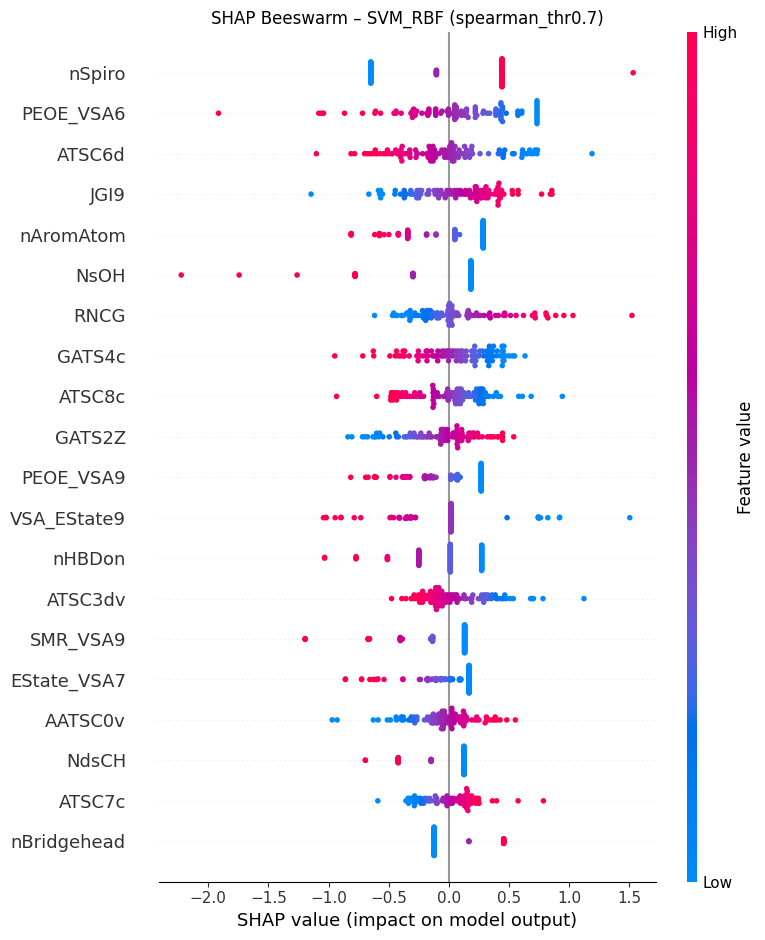

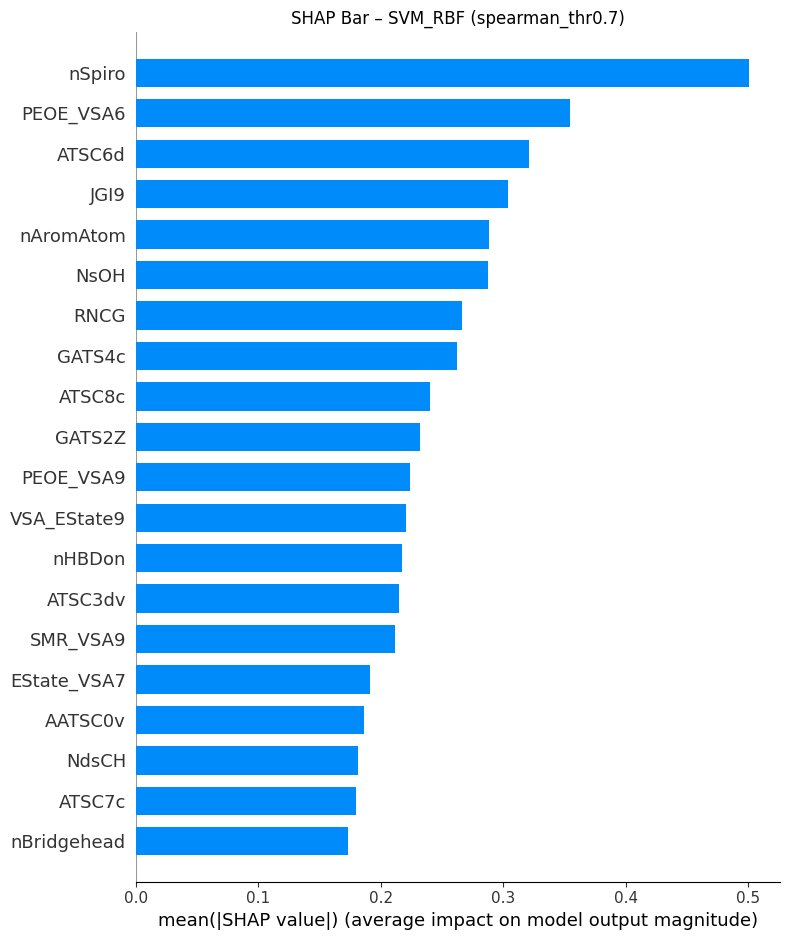

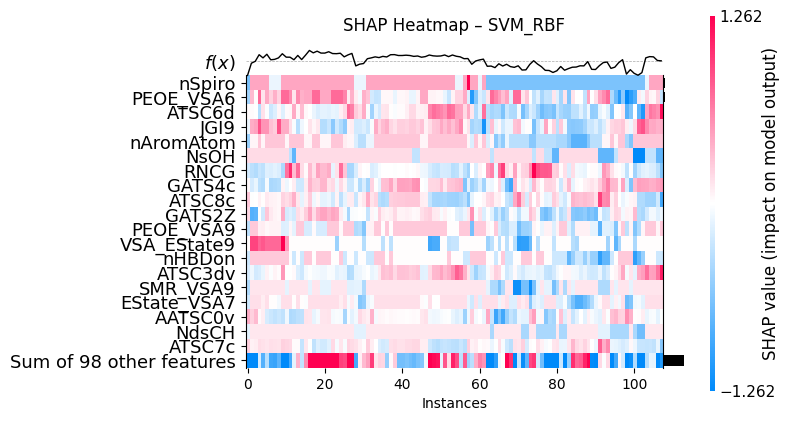


  Top 10 descriptores más influyentes (SVM_RBF):
descriptor  mean_abs_shap
    nSpiro       0.500693
 PEOE_VSA6       0.354047
    ATSC6d       0.321116
      JGI9       0.303378
 nAromAtom       0.288030
      NsOH       0.287737
      RNCG       0.266363
    GATS4c       0.262157
    ATSC8c       0.240228
    GATS2Z       0.231642

══ SHAP #4: LogisticRegression (pearson_thr0.7) ══
  Usando LinearExplainer...


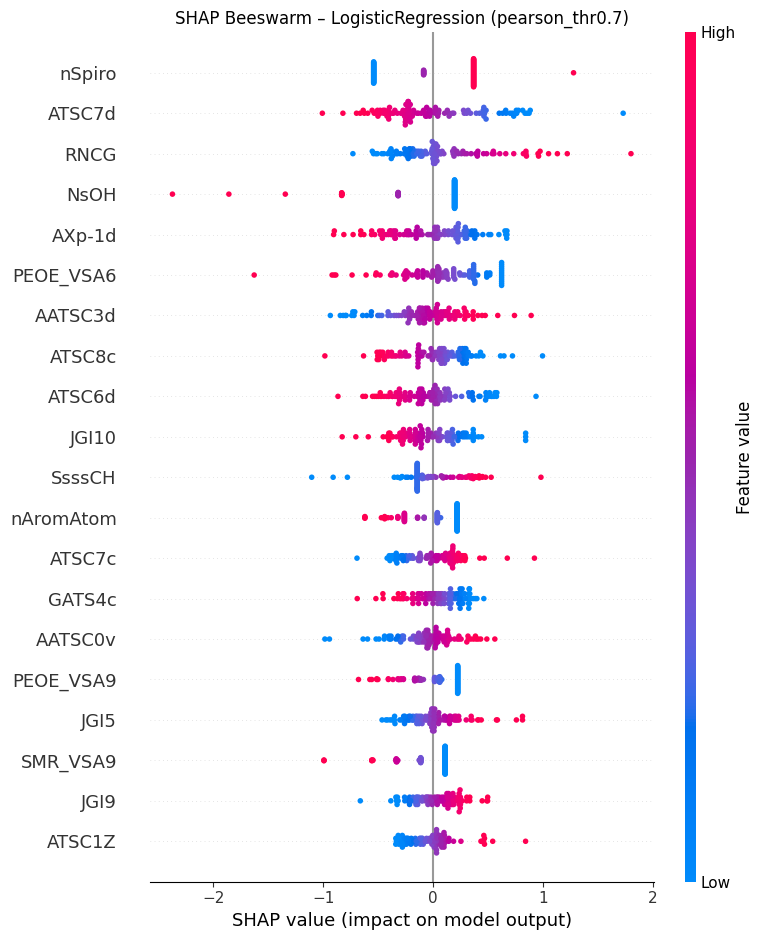

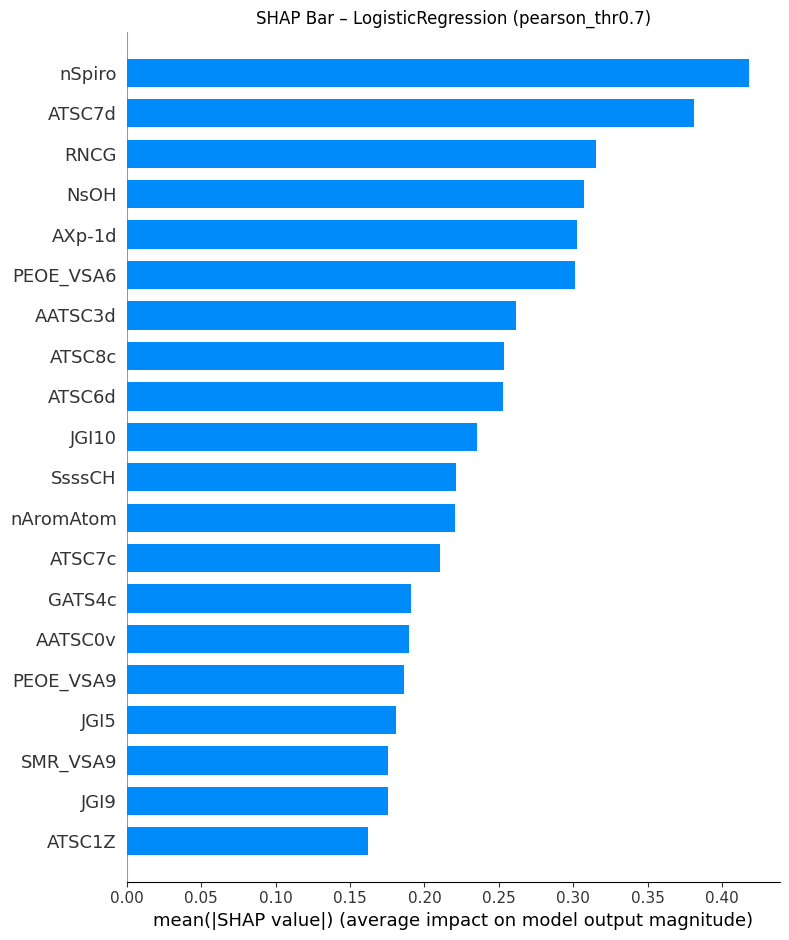

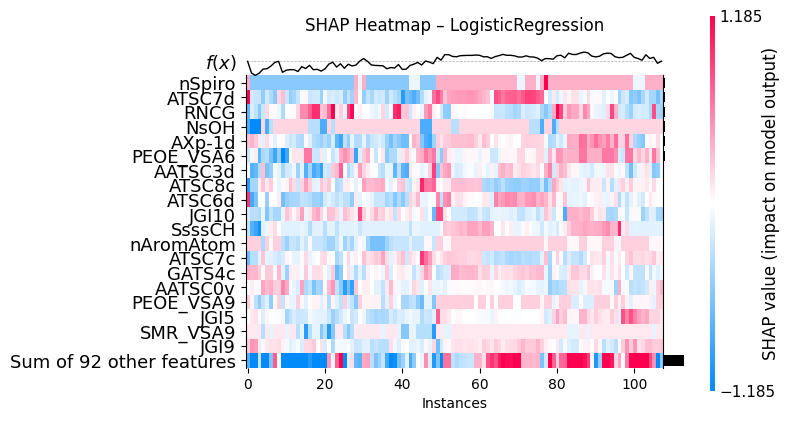


  Top 10 descriptores más influyentes (LogisticRegression):
descriptor  mean_abs_shap
    nSpiro       0.417892
    ATSC7d       0.381275
      RNCG       0.315263
      NsOH       0.307047
    AXp-1d       0.302597
 PEOE_VSA6       0.301274
   AATSC3d       0.261754
    ATSC8c       0.253640
    ATSC6d       0.252750
     JGI10       0.235096

══ SHAP #5: AdaBoost (pearson_thr0.7) ══
  Usando KernelExplainer (puede tardar varios minutos)...


100%|██████████| 108/108 [01:53<00:00,  1.05s/it]


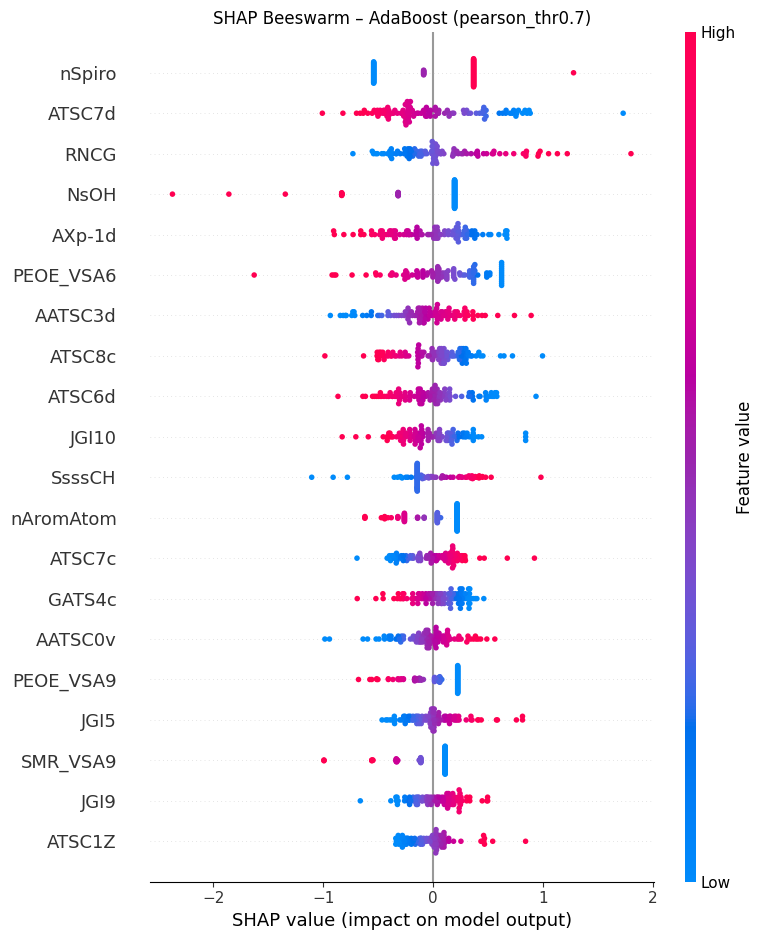

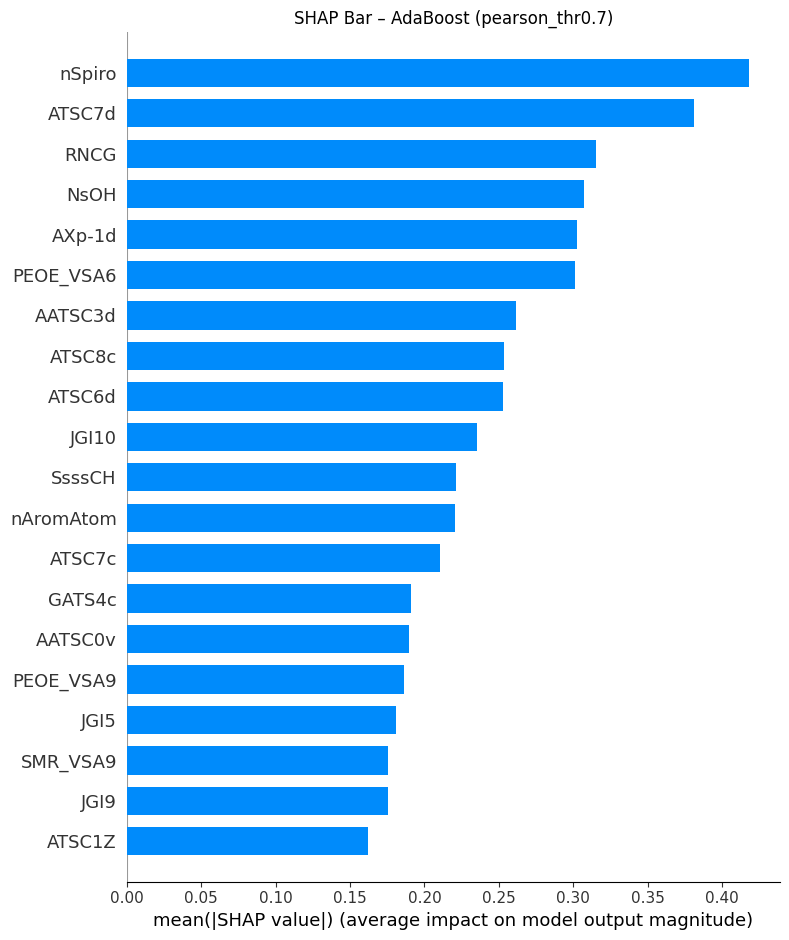

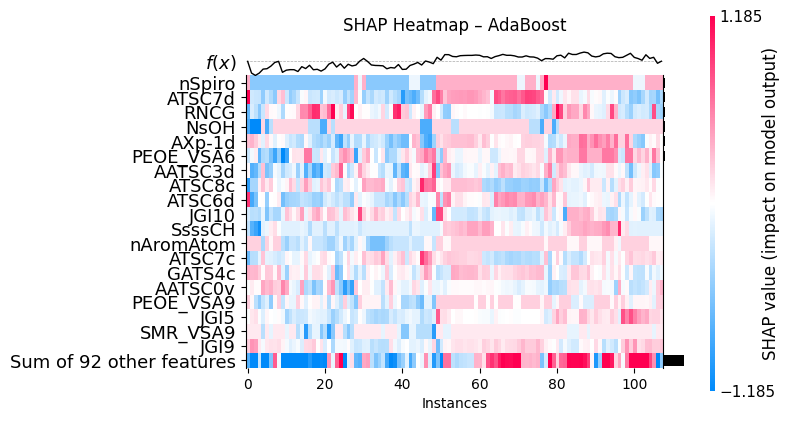


  Top 10 descriptores más influyentes (AdaBoost):
descriptor  mean_abs_shap
    nSpiro       0.417892
    ATSC7d       0.381275
      RNCG       0.315263
      NsOH       0.307047
    AXp-1d       0.302597
 PEOE_VSA6       0.301274
   AATSC3d       0.261754
    ATSC8c       0.253640
    ATSC6d       0.252750
     JGI10       0.235096

══ SHAP #6: SVM_RBF (pearson_thr0.7) ══
  Usando KernelExplainer (puede tardar varios minutos)...


100%|██████████| 108/108 [03:53<00:00,  2.16s/it]


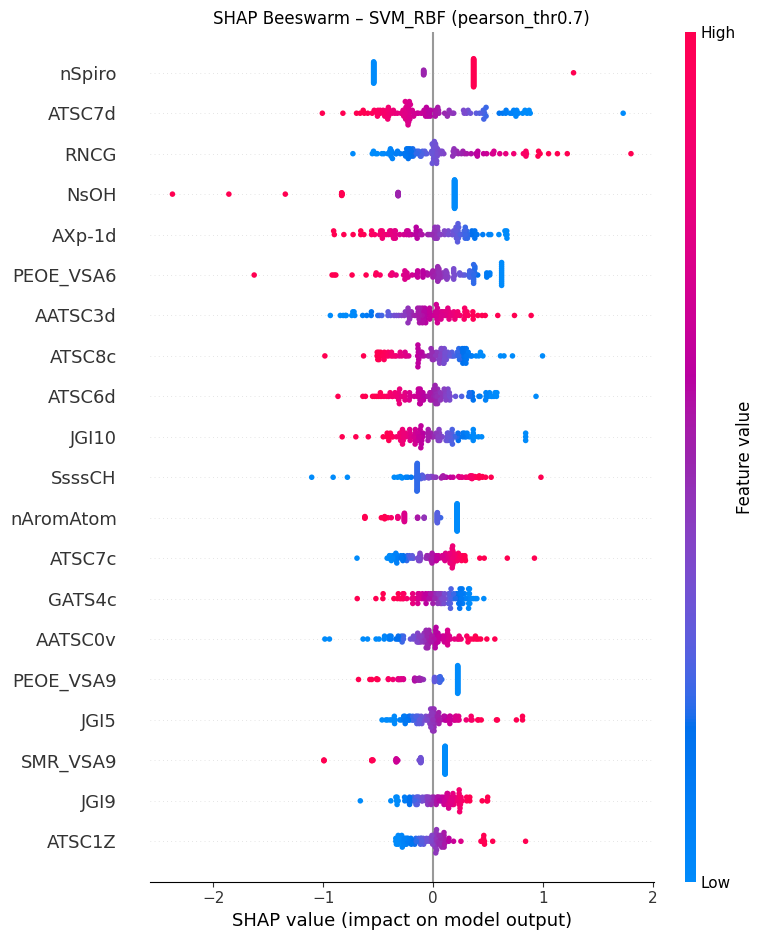

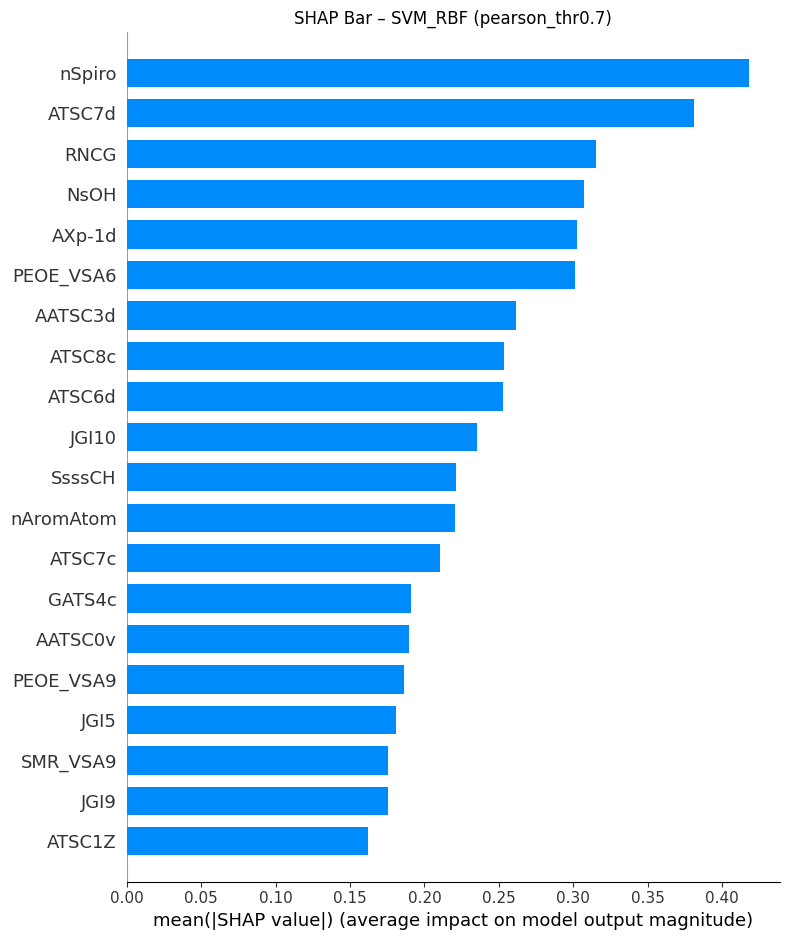

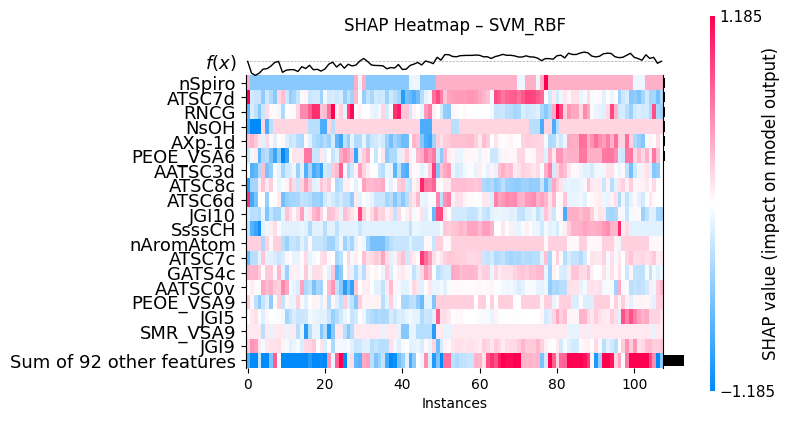


  Top 10 descriptores más influyentes (SVM_RBF):
descriptor  mean_abs_shap
    nSpiro       0.417892
    ATSC7d       0.381275
      RNCG       0.315263
      NsOH       0.307047
    AXp-1d       0.302597
 PEOE_VSA6       0.301274
   AATSC3d       0.261754
    ATSC8c       0.253640
    ATSC6d       0.252750
     JGI10       0.235096


In [27]:
# Tipos de modelos basados en árboles
TREE_TYPES = (RandomForestClassifier, ExtraTreesClassifier,
              GradientBoostingClassifier, DecisionTreeClassifier)
if HAS_XGB: TREE_TYPES = TREE_TYPES + (XGBClassifier,)
if HAS_LGB: TREE_TYPES = TREE_TYPES + (LGBMClassifier,)

# Tipos de modelos lineales
LINEAR_TYPES = (LogisticRegression, SGDClassifier)


for rank, (model_name, fs_name, _, _) in enumerate(TOP6_MODELS, start=1):
    key     = f'{model_name}__{fs_name}'
    est     = best_estimators[key]
    fs_cols = feature_sets[fs_name]
    clf_step = est.named_steps['clf']

    print(f'\n══ SHAP #{rank}: {model_name} ({fs_name}) ══')

    # Transformar X_test con los pasos previos al clasificador (imputer + scaler)
    X_te_transformed = est[:-1].transform(X_test_full[fs_cols])
    X_te_df = pd.DataFrame(X_te_transformed, columns=fs_cols)

    # También transformar X_train para usar como background en KernelExplainer
    X_tr_transformed = est[:-1].transform(X_train_full[fs_cols])
    X_tr_df = pd.DataFrame(X_tr_transformed, columns=fs_cols)

    try:
        # ── Selección del explainer ────────────────────────────────────────────
        if isinstance(clf_step, TREE_TYPES):
            print('  Usando TreeExplainer...')
            explainer = shap.TreeExplainer(clf_step)
            shap_vals = explainer.shap_values(X_te_df)
            sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals
            expected_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

        elif isinstance(clf_step, LINEAR_TYPES):
            print('  Usando LinearExplainer...')
            # Masker basado en los datos de entrenamiento (media + covarianza)
            masker    = shap.maskers.Independent(X_tr_df, max_samples=200)
            explainer = shap.LinearExplainer(clf_step, masker)
            shap_vals = explainer.shap_values(X_te_df)
            sv=shap_vals
            expected_val = explainer.expected_value

        else:
            # SVM RBF, KNN, MLP → KernelExplainer (más lento)
            print('  Usando KernelExplainer (puede tardar varios minutos)...')
            # Resumir el background con k-means para acelerar
            predict_fn = lambda x: clf_step.predict_proba(x)[:,1]
            background = shap.kmeans(X_tr_df, 30)
            #predict_fn = (clf_step.predict_proba
                          #if hasattr(clf_step, 'predict_proba')
                          #else clf_step.predict)
            # Usar solo una muestra del test para no tardar demasiado
            X_te_df   = X_te_df.reset_index(drop=True)
            explainer = shap.KernelExplainer(predict_fn, background)
            sv = explainer.shap_values(X_te_df, silent=False)
            expected_val = explainer.expected_value

        # Para clasificación binaria: tomar clase positiva (activo)
        sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

        # ── Plot 1: Beeswarm (distribución + dirección del efecto) ─────────────
        shap.summary_plot(sv, X_te_df, show=False, max_display=20, plot_type='dot')
        plt.title(f'SHAP Beeswarm – {model_name} ({fs_name})', fontsize=12)
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/shap_beeswarm_{rank}_{model_name}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

        # ── Plot 2: Bar (importancia media |SHAP|) ─────────────────────────────
        shap.summary_plot(sv, X_te_df, show=False, max_display=20, plot_type='bar')
        plt.title(f'SHAP Bar – {model_name} ({fs_name})', fontsize=12)
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/shap_bar_{rank}_{model_name}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

        # ── Plot 3: Heatmap SHAP (patrón global por compuesto) ─────────────────
        # Muestra qué descriptores dominan en cada compuesto individualmente
        shap_exp = shap.Explanation(
            values=sv,
            base_values=np.full(len(sv), explainer.expected_value
                                if not isinstance(explainer.expected_value, list)
                                else explainer.expected_value[1]),
            data=X_te_df.values,
            feature_names=fs_cols
        )
        shap.plots.heatmap(shap_exp, max_display=20, show=False)
        plt.title(f'SHAP Heatmap – {model_name}', fontsize=12)
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/shap_heatmap_{rank}_{model_name}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

        # ── Guardar SHAP values como CSV ───────────────────────────────────────
        shap_df = pd.DataFrame(sv, columns=fs_cols)
        shap_df.to_csv(f'{OUTPUT_DIR}/shap_values_{rank}_{model_name}.csv',
                       index=False)

        # ── Top 10 descriptores más influyentes (|SHAP| medio) ─────────────────
        top_shap = pd.DataFrame({
            'descriptor': fs_cols,
            'mean_abs_shap': np.abs(sv).mean(axis=0)
        }).sort_values('mean_abs_shap', ascending=False)

        print(f'\n  Top 10 descriptores más influyentes ({model_name}):')
        print(top_shap.head(10).to_string(index=False))

    except Exception as e:
        print(f'  ⚠️ Error en SHAP para {model_name}: {e}')

## 7. Análisis de dependencia SHAP (para el mejor modelo)

El dependence plot muestra cómo el valor de un descriptor específico
afecta a la predicción, con interacciones coloreadas por otro descriptor.

Top 5 descriptores para dependence plots: ['nSpiro', 'PEOE_VSA6', 'ATSC6d', 'JGI9', 'nAromAtom']


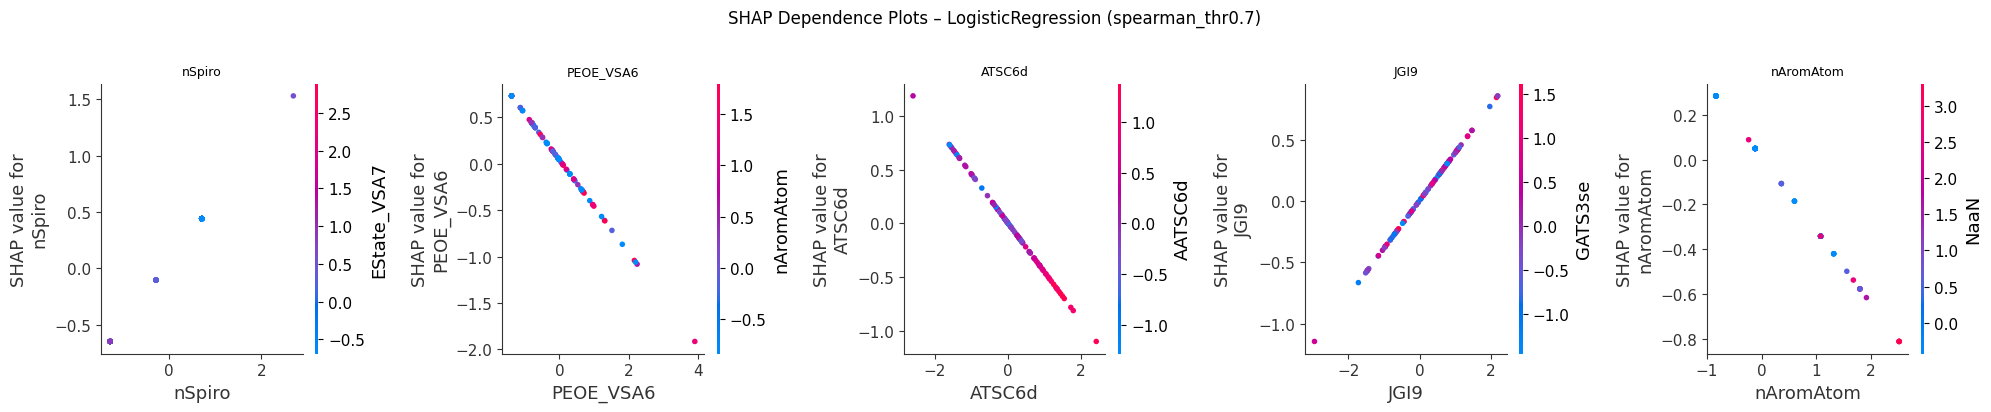

In [16]:
# Tomar el modelo #1 (mejor)
model_name, fs_name = TOP6_MODELS[0][0], TOP6_MODELS[0][1]
key     = f'{model_name}__{fs_name}'
est     = best_estimators[key]
fs_cols = feature_sets[fs_name]
clf_step = est.named_steps['clf']

X_te_transformed = est[:-1].transform(X_test_full[fs_cols])
X_te_df = pd.DataFrame(X_te_transformed, columns=fs_cols)

# Cargar los SHAP values ya calculados (CSV del paso anterior)
shap_df = pd.read_csv(f'{OUTPUT_DIR}/shap_values_1_{model_name}.csv')
sv = shap_df.values

# Top 5 descriptores por importancia SHAP media
top5_descriptors = pd.Series(
    np.abs(sv).mean(axis=0), index=fs_cols
).sort_values(ascending=False).head(5).index.tolist()

print(f'Top 5 descriptores para dependence plots: {top5_descriptors}')

# Dependence plot para cada uno de los top 5
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, feat in zip(axes, top5_descriptors):
    shap.dependence_plot(
        feat, sv, X_te_df,
        ax=ax, show=False,
        interaction_index='auto'  # colorea por el descriptor con más interacción
    )
    ax.set_title(feat, fontsize=9)

plt.suptitle(f'SHAP Dependence Plots – {model_name} ({fs_name})',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/shap_dependence_top5_{model_name}.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature importance intrínseca (solo modelos de árboles)

Comparación entre importancia Gini/Gain (intrínseca del modelo),
permutation importance y SHAP.

#1 LogisticRegression: sin feature_importances_ (no es árbol)


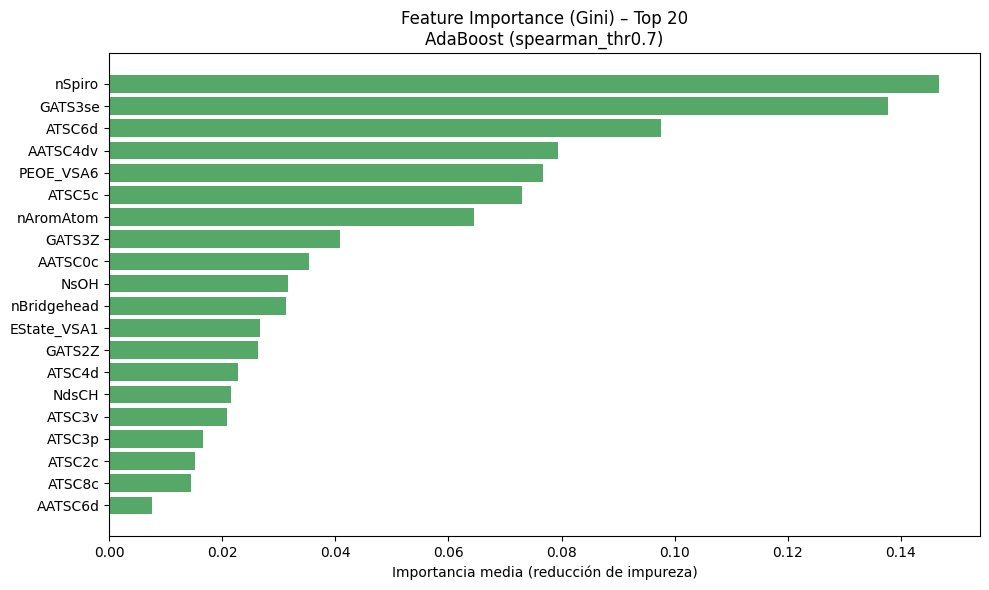

✅ #2 AdaBoost: gini_importance guardado.
#3 SVM_RBF: sin feature_importances_ (no es árbol)
#4 LogisticRegression: sin feature_importances_ (no es árbol)


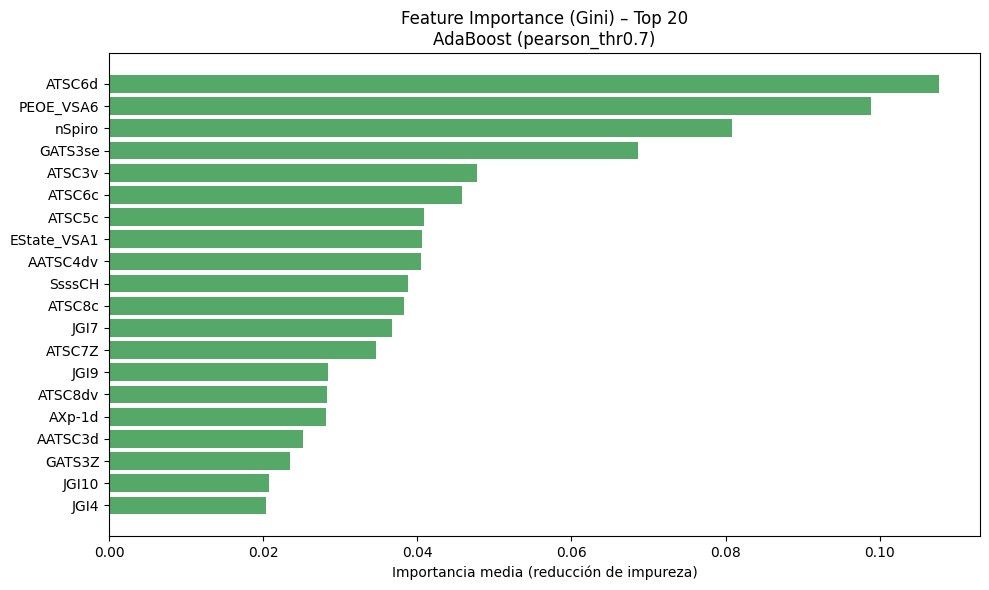

✅ #5 AdaBoost: gini_importance guardado.
#6 SVM_RBF: sin feature_importances_ (no es árbol)


In [17]:
for rank, (model_name, fs_name, _, _) in enumerate(TOP6_MODELS, start=1):
    key      = f'{model_name}__{fs_name}'
    est      = best_estimators[key]
    clf_step = est.named_steps['clf']
    fs_cols  = feature_sets[fs_name]

    if not hasattr(clf_step, 'feature_importances_'):
        print(f'#{rank} {model_name}: sin feature_importances_ (no es árbol)')
        continue

    fi_df = pd.DataFrame({
        'descriptor': fs_cols,
        'gini_importance': clf_step.feature_importances_
    }).sort_values('gini_importance', ascending=False)

    fi_df.to_csv(f'{OUTPUT_DIR}/gini_importance_{rank}_{model_name}.csv', index=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    top20 = fi_df.head(20)
    ax.barh(top20['descriptor'][::-1], top20['gini_importance'][::-1],
            color='#55A868')
    ax.set_title(f'Feature Importance (Gini) – Top 20\n{model_name} ({fs_name})')
    ax.set_xlabel('Importancia media (reducción de impureza)')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/gini_importance_{rank}_{model_name}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ #{rank} {model_name}: gini_importance guardado.')

## 9. Comparación de los tres métodos de importancia (para el mejor modelo)

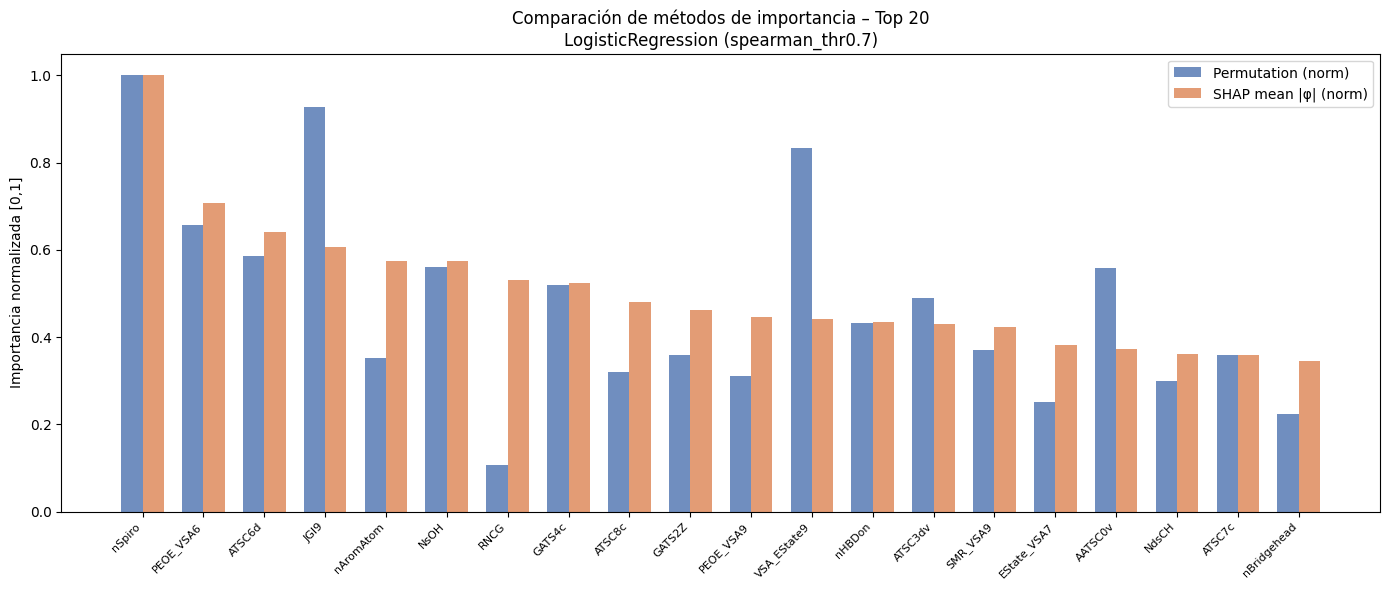

✅ Comparación guardada.


In [18]:
model_name, fs_name = TOP6_MODELS[0][0], TOP6_MODELS[0][1]

# Cargar los tres CSVs
perm_df  = pd.read_csv(f'{OUTPUT_DIR}/permutation_importance_1_{model_name}.csv')
shap_df2 = pd.read_csv(f'{OUTPUT_DIR}/shap_values_1_{model_name}.csv')

shap_mean = pd.DataFrame({
    'descriptor': shap_df2.columns,
    'shap_importance': np.abs(shap_df2.values).mean(axis=0)
})

# Merge de los tres métodos
compare = perm_df.rename(columns={
    'feature': 'descriptor',
    'importance_mean': 'perm_importance'
})[['descriptor', 'perm_importance']].merge(
    shap_mean, on='descriptor', how='inner'
)

# Añadir Gini si el modelo es árbol
gini_path = f'{OUTPUT_DIR}/gini_importance_1_{model_name}.csv'
if os.path.exists(gini_path):
    gini_df = pd.read_csv(gini_path)
    compare = compare.merge(
        gini_df.rename(columns={'gini_importance': 'gini_imp'}),
        on='descriptor', how='left'
    )

# Normalizar entre 0 y 1 para comparación visual
for col in ['perm_importance', 'shap_importance']:
    rng = compare[col].max() - compare[col].min()
    compare[col + '_norm'] = (compare[col] - compare[col].min()) / rng if rng > 0 else 0

compare = compare.sort_values('shap_importance_norm', ascending=False)
compare.to_csv(f'{OUTPUT_DIR}/comparacion_importancias_{model_name}.csv', index=False)

# Gráfico comparativo top 20
top20c = compare.head(20)
x = np.arange(len(top20c))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, top20c['perm_importance_norm'], width,
       label='Permutation (norm)', color='#4C72B0', alpha=0.8)
ax.bar(x + width/2, top20c['shap_importance_norm'], width,
       label='SHAP mean |φ| (norm)', color='#DD8452', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(top20c['descriptor'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Importancia normalizada [0,1]')
ax.set_title(f'Comparación de métodos de importancia – Top 20\n{model_name} ({fs_name})')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/comparacion_importancias_{model_name}.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparación guardada.')

## Applicability Domain — the concept

The Applicability Domain (AD) defines the chemical space in which the model's predictions are reliable. A molecule outside the AD is structurally dissimilar from the training set — its prediction is an extrapolation.

We use the leverage method (Williams Plot):

- Hat value (h): measures how far a molecule is from the centroid of the training set in descriptor space
- Threshold h* = 3(k+1)/n: where k = number of features, n = training set size
- Molecules with h > h* are flagged as outside the AD

Important: being outside the AD does NOT mean inactive. It means the model has limited basis to make that specific prediction. Always cross-validate with docking.